# Part 1 Data Exploration
This notebook covers the first part of the project:
1. Load the dataset
2. Display number of samples and distribution of classes
3. Print 5 positive and 5 negative reviews
4. Analyze average review length

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the dataset
print("Loading datasets...")
train_df = pd.read_csv('../data/imdb_train.csv')
test_df = pd.read_csv('../data/imdb_test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Loading datasets...
Train shape: (25000, 2)
Test shape: (25000, 2)


## Number of samples & Distribution of classes

--- Training Data Class Distribution ---
sentiment
Negative    12500
Positive    12500
Name: count, dtype: int64

--- Testing Data Class Distribution ---
sentiment
Negative    12500
Positive    12500
Name: count, dtype: int64


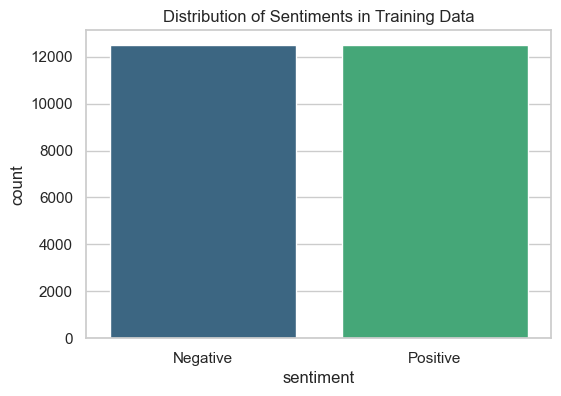

In [2]:
print("--- Training Data Class Distribution ---")
print(train_df['sentiment'].value_counts())
print("\n--- Testing Data Class Distribution ---")
print(test_df['sentiment'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='sentiment', hue='sentiment', palette='viridis', legend=False)
plt.title('Distribution of Sentiments in Training Data')
plt.show()

## Print 5 Positive and 5 Negative Reviews

In [3]:
print("--- 5 POSITIVE REVIEWS ---\n")
positive_reviews = train_df[train_df['sentiment'] == 'Positive']['text'].head(5)
for i, review in enumerate(positive_reviews, 1):
    print(f"[{i}] {review[:400]}...\n")

print("\n--- 5 NEGATIVE REVIEWS ---\n")
negative_reviews = train_df[train_df['sentiment'] == 'Negative']['text'].head(5)
for i, review in enumerate(negative_reviews, 1):
    print(f"[{i}] {review[:400]}...\n")

--- 5 POSITIVE REVIEWS ---

[1] Zentropa has much in common with The Third Man, another noir-like film set among the rubble of postwar Europe. Like TTM, there is much inventive camera work. There is an innocent American who gets emotionally involved with a woman he doesn't really understand, and whose naivety is all the more striking in contrast with the natives.<br /><br />But I'd have to say that The Third Man has a more well-...

[2] Zentropa is the most original movie I've seen in years. If you like unique thrillers that are influenced by film noir, then this is just the right cure for all of those Hollywood summer blockbusters clogging the theaters these days. Von Trier's follow-ups like Breaking the Waves have gotten more acclaim, but this is really his best work. It is flashy without being distracting and offers the perfec...

[3] Lars Von Trier is never backward in trying out new techniques. Some of them are very original while others are best forgotten.<br /><br />He depicts p

## Analyze Average Review Length
Let's analyze the length of the reviews by word count. This helps us understand how long our sequences are, which is important for Transformer models later.

Average word count: 233.79
Median word count: 174.0
Max word count: 2470
Min word count: 10


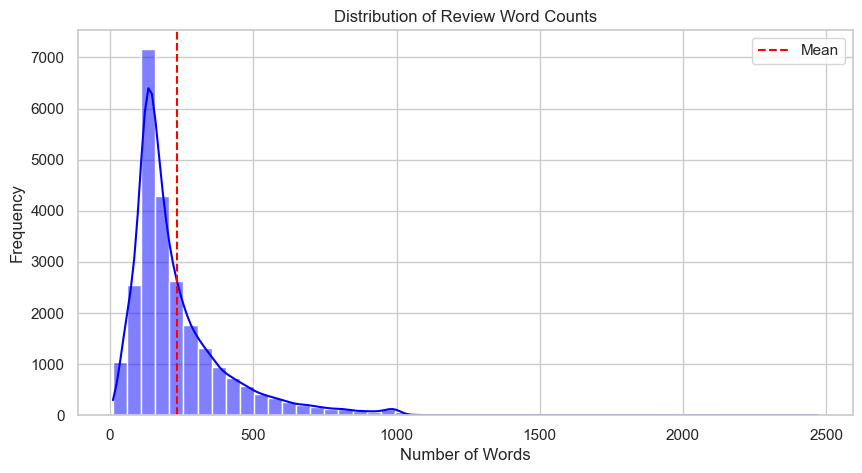

In [4]:
# Calculate word count for each review
train_df['word_count'] = train_df['text'].apply(lambda x: len(x.split()))

print("Average word count:", round(train_df['word_count'].mean(), 2))
print("Median word count:", train_df['word_count'].median())
print("Max word count:", train_df['word_count'].max())
print("Min word count:", train_df['word_count'].min())

plt.figure(figsize=(10,5))
sns.histplot(train_df['word_count'], bins=50, kde=True, color='blue')
plt.title('Distribution of Review Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(x=train_df['word_count'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.show()